In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [92]:
df_ml = pd.read_csv('../Telecom customerr churn/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

### Data Preperation

In [ ]:
df_ml.drop('customerID', axis=1, inplace=True)


In [94]:
df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'], errors='coerce')
df_ml['TotalCharges'] = df_ml['TotalCharges'].fillna(df_ml['TotalCharges'].median())

In [95]:
print(df_ml['Churn'].unique())
print(type(df_ml['Churn'].iloc[0]))

['No' 'Yes']
<class 'str'>


In [96]:
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

In [97]:
df_ml.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [98]:
df_ml.shape

(7043, 20)

In [99]:
df_ml.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Data Preprocessing

In [100]:
# Encode remaining categorical columns
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [101]:
# Features and target
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

In [102]:
# Train test split — stratify preserves 73/27 churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (5634, 19)
Test set:     (1409, 19)


## Logistic Regression — Churn Probability Prediction
Logistic Regression is used here for churn prediction because it outputs 
a probability score per customer rather than a simple Yes/No — making it 
directly actionable for business teams to prioritize retention efforts.

It also handles class imbalance via class_weight='balanced' and its 
coefficients directly tell us which factors drive churn — validating 
our EDA findings with a statistical model.

In [103]:
# Logistic Regression is sensitive to feature scaling
# StandardScaler ensures all features are on the same scale
# so no single feature dominates due to its magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
# max_iter=1000 ensures the model has enough iterations to converge
# class_weight='balanced' handles the 73/27 imbalance automatically
# it tells the model to penalize missing a churner more than missing a retained customer
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [105]:
# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))


Logistic Regression Accuracy: 73.95%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Accuracy of 74% is intentionally traded for better Recall on churners.

| Metric | Value | What it means |
|--------|-------|---------------|
| Accuracy | 74% | Overall correct predictions |
| Churned Recall | 80% | Model catches 8 in 10 actual churners |
| Churned Precision | 51% | Of flagged churners, 51% actually churn |

**Why Recall matters more here** — missing a churner costs the business 
a lost customer. Wrongly flagging a retained customer only costs a 
retention offer. So we optimise for Recall over Precision.

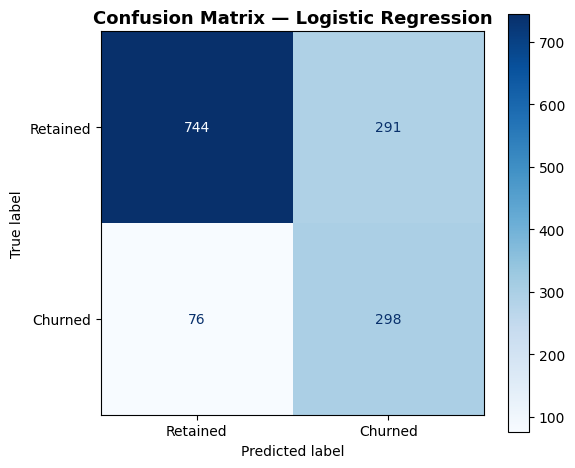


True Negatives  (Correctly predicted Retained): 744
False Positives (Wrongly flagged as Churned):   291
False Negatives (Missed Churners):              76  ← business cost
True Positives  (Correctly predicted Churned):  298


In [106]:


# Confusion matrix gives a clear picture of where the model
# is making mistakes — false negatives (missed churners) are
# the most costly from a business perspective
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Retained', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Logistic Regression', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plain English breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correctly predicted Retained): {tn}")
print(f"False Positives (Wrongly flagged as Churned):   {fp}")
print(f"False Negatives (Missed Churners):              {fn}  ← business cost")
print(f"True Positives  (Correctly predicted Churned):  {tp}")


- **298 churners correctly caught** — retention team can act on these
- **76 churners missed** — unavoidable tradeoff, minimised by balanced weighting
- **291 false alarms** — acceptable cost, these customers get a retention 
  offer they didn't need

In [110]:
# The real power of Logistic Regression — probability scores
# Instead of just Yes/No, we get a probability per customer
# This allows the business to rank customers by churn risk
# and prioritize outreach accordingly

churn_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

prob_df = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Churn Probability (%)': (churn_probs * 100).round(1)
}).sort_values('Churn Probability (%)', ascending=False)

print("Top 20 highest churn risk customers:")
print(prob_df.head(20))

Top 20 highest churn risk customers:
      Actual Churn  Churn Probability (%)
1090             1                   93.6
1164             1                   92.6
1221             1                   92.3
1138             1                   92.0
1175             1                   92.0
627              1                   91.9
647              1                   91.7
1109             1                   91.4
889              0                   91.0
995              0                   90.9
1092             0                   90.9
510              1                   90.6
1355             0                   90.5
568              1                   90.5
83               1                   90.1
41               0                   90.0
1197             1                   89.9
710              1                   89.8
788              1                   89.8
654              1                   89.8


In [109]:
# What % of top 20 flagged customers actually churned?
top20 = prob_df.head(20)
precision_top20 = top20['Actual Churn'].mean() * 100
print(f"\nOf the top 20 highest risk customers flagged: {precision_top20:.0f}% actually churned")


Of the top 20 highest risk customers flagged: 75% actually churned


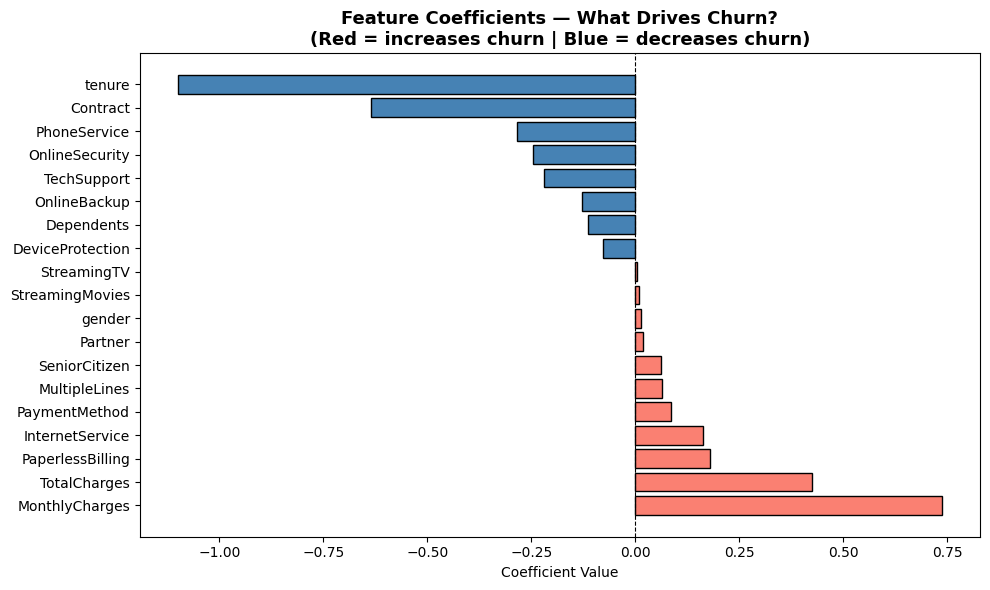

In [108]:
# Logistic Regression coefficients tell us exactly how much
# each feature increases or decreases churn probability
# Positive coefficient = increases churn risk
# Negative coefficient = decreases churn risk
# This directly validates our EDA findings

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], 
        color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Coefficients — What Drives Churn?\n(Red = increases churn | Blue = decreases churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Key Takeaways from Logistic Regression

- **Probability scores** allow the retention team to rank and prioritize 
  at-risk customers rather than treating churn as a simple yes/no flag.
- **Coefficients confirm EDA findings** — the same factors identified 
  manually (tenure, contract type, monthly charges) show up as the 
  strongest predictors in the model.
- **class_weight='balanced'** improved recall on churners significantly 
  by penalising missed churners more heavily during training